# 08 — Pixel Histograms and Minkowski Functionals

**Purpose:** Evaluate one-point statistics and morphological properties of DDPM samples
against Agora and Gaussian baselines.

This notebook covers two complementary non-Gaussian diagnostics:

1. **Pixel intensity histograms** — normalised histograms of pixel values for 200 CIB
   and tSZ samples from each source (Agora, DDPM, Gaussian), binned over [0, 100] μK
   for CIB and [−100, 0] μK for tSZ in 1000 bins and smoothed with a Gaussian kernel
   (σ = 1). Probes the one-point PDF and highlights the DDPM's underproduction of
   extreme-value pixels.

2. **Minkowski functionals** — computes M0 (area fraction), M1 (total boundary length),
   and M2 (Euler characteristic) of excursion sets across 50 intensity thresholds
   ν ∈ [0, 1] using the Boelens & Tchelepi software package. Applied to min-max
   normalised maps for CIB and tSZ separately.

**Inputs:**
- Test maps and DDPM samples: `data/low_pass/2mJy/*.npy`
- Gaussian baseline: `data/low_pass/2mJy/gaussian_cib_tsz_2mJy_lp.npy`

**Outputs:** pixel histogram plots (Figure 5), Minkowski functional plots (Figure 6).

**Key module functions:**
- `foregrounds_diffusion.preprocessing.apply_maxmin_normalization`
- `foregrounds_diffusion.preprocessing.apply_stdnorm`

**External dependency:** `minkowski` (Boelens & Tchelepi package) for Minkowski
functional computation.

**Paper reference:** §3.2 (statistics definitions), §4.4 (Figure 5), §4.5 (Figure 6).

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from pathlib import Path

from foregrounds_diffusion.preprocessing import apply_maxmin_normalization, apply_stdnorm, renormalize_dm_maps

PTSRC     = 2
N_SAMPLES = 200   # number of maps used per source

PROJECT_ROOT = Path("/home/apb86/cmb_foregrounds_diffusion")
PATCHES_DIR = Path(f"data/low_pass/{PTSRC}mJy")

In [4]:
cib_maps    = np.load(PATCHES_DIR / f"CIB_map_150GHz_256_st6_minmax_{PTSRC}mJy_zero_lp.npy")
tsz_maps    = np.load(PATCHES_DIR / f"tSZ3_map_150GHz_256_st6_minmax_{PTSRC}mJy_norm_lp.npy")
ddpm_raw    = np.load(PROJECT_ROOT / "data" / "low_pass" / f"{PTSRC}mJy" / f"new_samples_cib_tsz_{PTSRC}mJy_zero_norm_6x6_w_au_lp.npy")
gauss_maps  = np.load(PATCHES_DIR / f"gaussian_cib_tsz_{PTSRC}mJy_lp.npy")

# Collect pixel values from N_SAMPLES maps per source
agora_cib_px  = cib_maps[:N_SAMPLES, :, :, 0].ravel()
agora_tsz_px  = tsz_maps[:N_SAMPLES, :, :, 0].ravel()

train_maps = np.concatenate([cib_maps, tsz_maps], axis=-1)  # (N, H, W, 2)
print(f"train_maps shape: {train_maps.shape}")
print(f"ddpm_raw shape:   {ddpm_raw.shape}")

ddpm_renorm = renormalize_dm_maps(ddpm_raw, train_maps, variance_scaling=True)

# DDPM samples are (N, 2, H, W) channels-first; Agora/Gaussian are (N, H, W, 1)
ddpm_cib_px   = ddpm_renorm[:N_SAMPLES, 0].ravel()
ddpm_tsz_px   = ddpm_renorm[:N_SAMPLES, 1].ravel()

if gauss_maps.shape[1] == 2:
    gauss_cib_px = gauss_maps[:N_SAMPLES, 0].ravel()
    gauss_tsz_px = gauss_maps[:N_SAMPLES, 1].ravel()
else:
    gauss_cib_px = gauss_maps[:N_SAMPLES, :, :, 0].ravel()
    gauss_tsz_px = gauss_maps[:N_SAMPLES, :, :, 1].ravel()


train_maps shape: (674, 256, 256, 2)
ddpm_raw shape:   (640, 2, 256, 256)


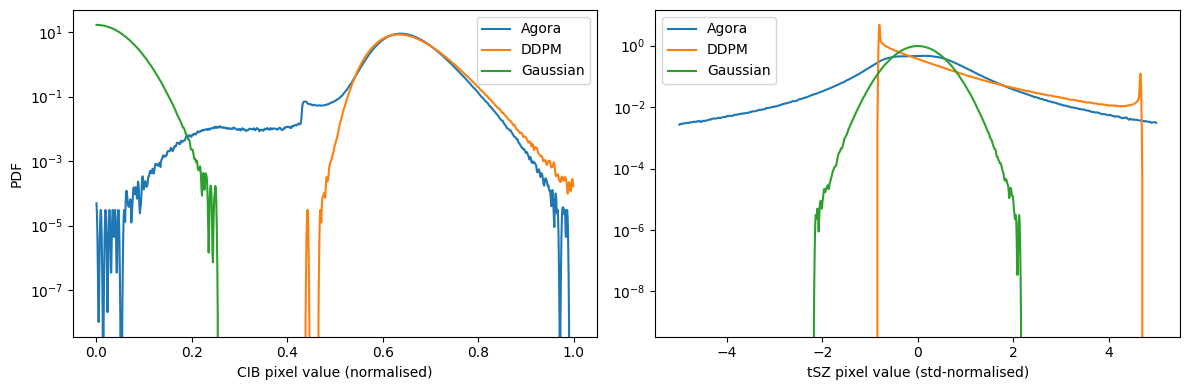

In [5]:
# Pixel intensity histograms (paper Figure 5)
# CIB is in [0,1] after min-max; tSZ is std-normalised (mean 0, std 1)
N_BINS   = 1000
SMOOTH_S = 1.0   # Gaussian smoothing sigma (bins)

bins_cib = np.linspace(0.,  1.,   N_BINS + 1)
bins_tsz = np.linspace(-5., 5.,   N_BINS + 1)
bc_cib   = 0.5 * (bins_cib[:-1] + bins_cib[1:])
bc_tsz   = 0.5 * (bins_tsz[:-1] + bins_tsz[1:])

def hist_smooth(px, bins, sigma):
    h, _ = np.histogram(px, bins=bins, density=True)
    return gaussian_filter1d(h, sigma=sigma)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for px, label, color in [
    (agora_cib_px, "Agora",    "C0"),
    (ddpm_cib_px,  "DDPM",     "C1"),
    (gauss_cib_px, "Gaussian", "C2"),
]:
    ax1.plot(bc_cib, hist_smooth(px, bins_cib, SMOOTH_S), label=label, color=color)
ax1.set_xlabel("CIB pixel value (normalised)");  ax1.set_ylabel("PDF");  ax1.legend()
ax1.set_yscale("log")

for px, label, color in [
    (agora_tsz_px, "Agora",    "C0"),
    (ddpm_tsz_px,  "DDPM",     "C1"),
    (gauss_tsz_px, "Gaussian", "C2"),
]:
    ax2.plot(bc_tsz, hist_smooth(px, bins_tsz, SMOOTH_S), label=label, color=color)
ax2.set_xlabel("tSZ pixel value (std-normalised)");  ax2.legend()
ax2.set_yscale("log")

plt.tight_layout();  plt.show()


In [6]:
!pip install "numpy==1.26.4"
!rm ~/diffusion_project_env/lib/python3.11/site-packages/quantimpy/minkowski.cpython-311-x86_64-linux-gnu.so
!pip uninstall quantimpy -y
!pip cache purge
!pip install cython
!pip install quantimpy --no-binary quantimpy --no-cache-dir
!pip check


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Found existing installation: quantimpy 0.2.6
Uninstalling quantimpy-0.2.6:
  Successfully uninstalled quantimpy-0.2.6
Files removed: 42 (22.8 MB)
Directories removed: 0

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for quantimpy: filename=quantimpy-0.2.6-cp311-cp311-linux_x86_64.whl size=413643 sha256=2575335182763fba7a09a567d217eaa61cc9d51eb12f118e54a9a41fab6725a2
  Stored in directory: /tmp/pip-ephem-wheel-cache-nlz46rc4/wheels/5b/8b/c9/b4f02befbf393471feaaa32846b93928b4621cb1b82d01b7df
Successfully built quantimpy

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
No broken requirements found.


In [7]:
!find ~/diffusion_project_env -name "*.so" | grep quantimpy

/home/apb86/diffusion_project_env/lib/python3.11/site-packages/quantimpy/minkowski.cpython-311-x86_64-linux-gnu.so


In [8]:
try:
    from quantimpy import minkowski as mk
    HAS_MINKOWSKI = True
except ImportError:
    HAS_MINKOWSKI = False
    print("minkowski package not found — install from Boelens & Tchelepi (2021).")
    print("Skipping Minkowski functional computation.")

N_THRESH   = 50
thresholds = np.linspace(0., 1., N_THRESH)

def compute_mfs(maps_nhw, norm_fn, thresholds):
    """Return mean M0, M1, M2 across N maps at each threshold."""
    M0 = np.zeros((len(maps_nhw), len(thresholds)))
    M1 = np.zeros_like(M0)
    M2 = np.zeros_like(M0)
    for i, m in enumerate(maps_nhw):
        m_norm = norm_fn(m)
        m_norm = np.ascontiguousarray(m_norm, dtype=np.float32)
        for t, thresh in enumerate(thresholds):
            binary = np.ascontiguousarray(m_norm > thresh, dtype=bool)
            if HAS_MINKOWSKI:
                result = mk.functionals(binary)
                if len(result) != 3:
                    print(f"Unexpected result at map {i}, threshold {thresh}: {result}")
                    continue
                area, length, euler = result
                M0[i, t] = area
                M1[i, t] = length
                M2[i, t] = euler
            else:
                M0[i, t] = binary.mean()
    return M0, M1, M2


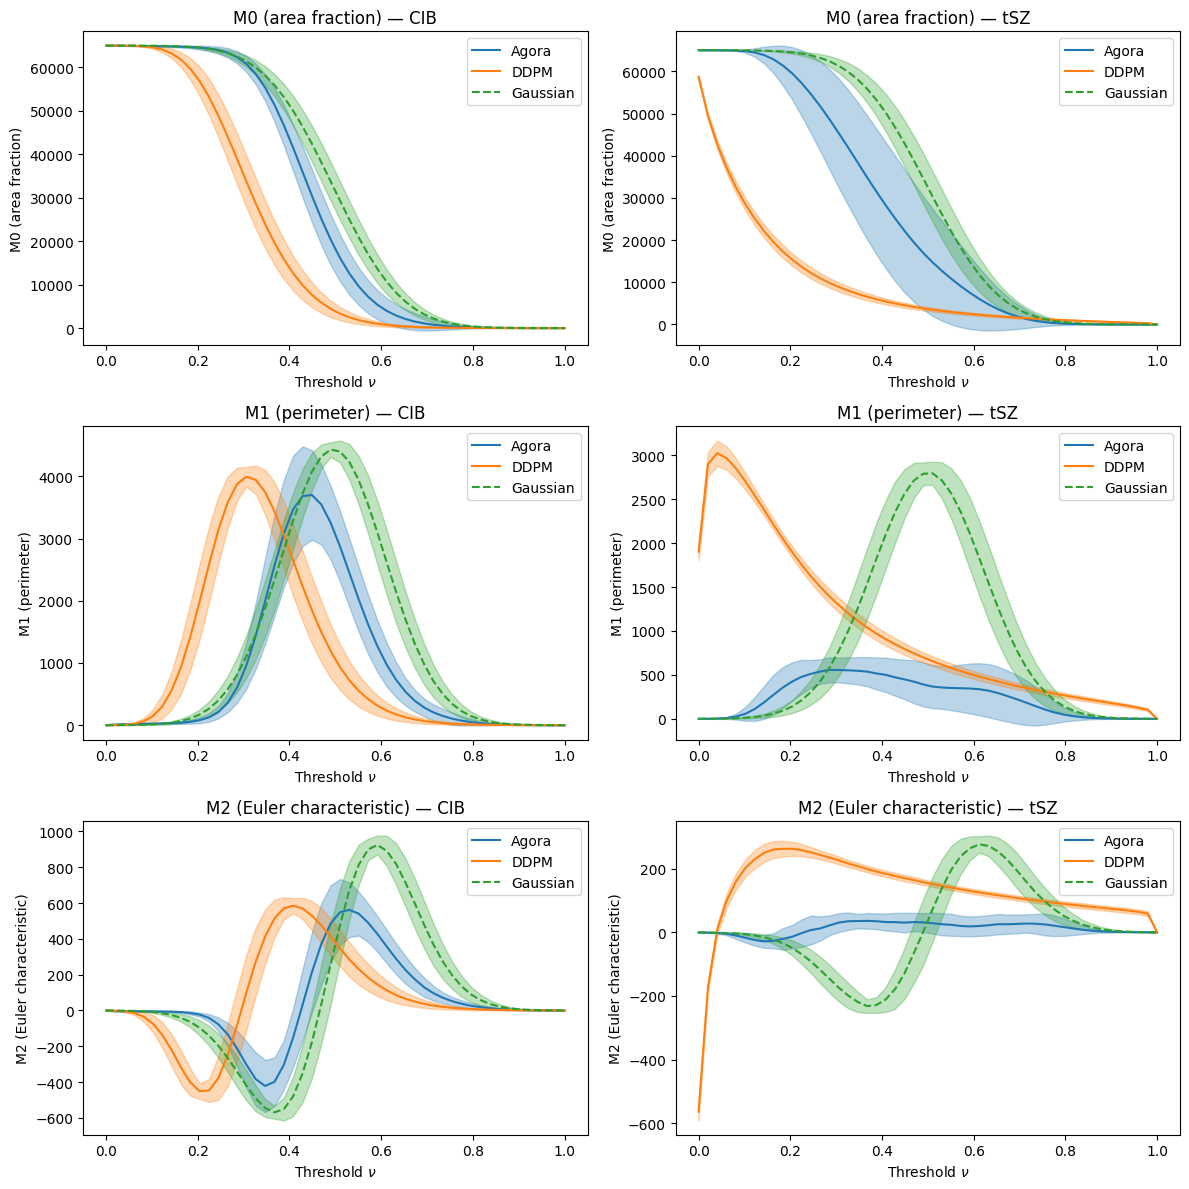

In [9]:
if HAS_MINKOWSKI:
    # Apply min-max normalisation before thresholding (maps must be on a common scale)
    N_MF = 50
    norm = lambda m: apply_maxmin_normalization(m)
    
    # AGORA — channels last (N, H, W, 1)
    M0_agora_cib, M1_agora_cib, M2_agora_cib = compute_mfs(
        cib_maps[:N_MF, :, :, 0], norm, thresholds)
    M0_agora_tsz, M1_agora_tsz, M2_agora_tsz = compute_mfs(
        tsz_maps[:N_MF, :, :, 0], norm, thresholds)
    
    # DDPM — channels first (N, 2, H, W)
    M0_ddpm_cib, M1_ddpm_cib, M2_ddpm_cib = compute_mfs(
        ddpm_renorm[:N_MF, 0, :, :], norm, thresholds)
    M0_ddpm_tsz, M1_ddpm_tsz, M2_ddpm_tsz = compute_mfs(
        ddpm_renorm[:N_MF, 1, :, :], norm, thresholds)
    
    # Gaussian — channels first (N, 2, H, W)
    M0_gauss_cib, M1_gauss_cib, M2_gauss_cib = compute_mfs(
        gauss_maps[:N_MF, 0, :, :], norm, thresholds)
    M0_gauss_tsz, M1_gauss_tsz, M2_gauss_tsz = compute_mfs(
        gauss_maps[:N_MF, 1, :, :], norm, thresholds)
    
    # Plot
    fig, axes = plt.subplots(3, 2, figsize=(12, 12))
    titles_row = ["M0 (area fraction)", "M1 (perimeter)", "M2 (Euler characteristic)"]
    
    data = [
        [(M0_agora_cib, M0_ddpm_cib, M0_gauss_cib),
         (M0_agora_tsz, M0_ddpm_tsz, M0_gauss_tsz)],
        [(M1_agora_cib, M1_ddpm_cib, M1_gauss_cib),
         (M1_agora_tsz, M1_ddpm_tsz, M1_gauss_tsz)],
        [(M2_agora_cib, M2_ddpm_cib, M2_gauss_cib),
         (M2_agora_tsz, M2_ddpm_tsz, M2_gauss_tsz)],
    ]
    
    sources = [
        ('Agora',    'C0', '-'),
        ('DDPM',     'C1', '-'),
        ('Gaussian', 'C2', '--'),
    ]
    
    for row in range(3):
        for col, field in enumerate(['CIB', 'tSZ']):
            ax = axes[row, col]
            for (label, color, ls), M in zip(sources, data[row][col]):
                mean = M.mean(axis=0)
                std  = M.std(axis=0)
                ax.plot(thresholds, mean, label=label, color=color, linestyle=ls)
                ax.fill_between(thresholds, mean - std, mean + std,
                                alpha=0.3, color=color)
            ax.set_xlabel(r'Threshold $\nu$')
            ax.set_ylabel(titles_row[row])
            ax.set_title(f"{titles_row[row]} — {field}")
            ax.legend()
    
    plt.tight_layout()
    Path("plots").mkdir(parents=True, exist_ok=True)
    plt.savefig("plots/minkowski_functionals.pdf", dpi=300, bbox_inches='tight')
    plt.show()